In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

from rebin_utils import downsample, oversample

#  H II region Data

In [3]:
line        = r'H$\alpha$'
lambda_rest = 6562.8
line_id     = 'H'
line_id2   = "H_I-6563"

In [4]:
# Data from observations
bins        = 0

region     = 'M 42'
name_reg   = 'Orion'
reg_id     = 'M42'
inst       = 'MUSE'
inst_id    = 'MUSE'
type_obj   = 'H II region'

pix        = 0.2   # Instrument resolution [arcsec/pix]
dist       = 410 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60) # value in parsecs of each arcsec
s0         = (s0_*pc) / 2.355    # RMS seeing [parsecs]

#Since we are working with matrix data binning can be applied
#name_file    =  inst_id + '-' + reg_id + '-' + line_id 
name_file    =  line_id2 
name_id      =  inst_id + '-' + reg_id + '-' + line_id + '-' + 'bin' + str(bins) + '-cont'
print(name_file)
print(name_id)

H_I-6563
MUSE-M42-H-bin0-cont


In [5]:
from pipeline_config import OBSERVATIONS_DIR

flux_path    = OBSERVATIONS_DIR / f'linesum-{name_file}.fits'
radvel_path  = OBSERVATIONS_DIR / f'mean-{name_file}-patfixx.fits'

# Open files
flux    = fits.open(flux_path)
rad_vel = fits.open(radvel_path)

In [6]:
sb = flux[0].data.astype(float)
vv = rad_vel[0].data.astype(float)
#ss    = np.array(_data['ss'])

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\3387000891.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 0.8, 'H$\\alpha$')

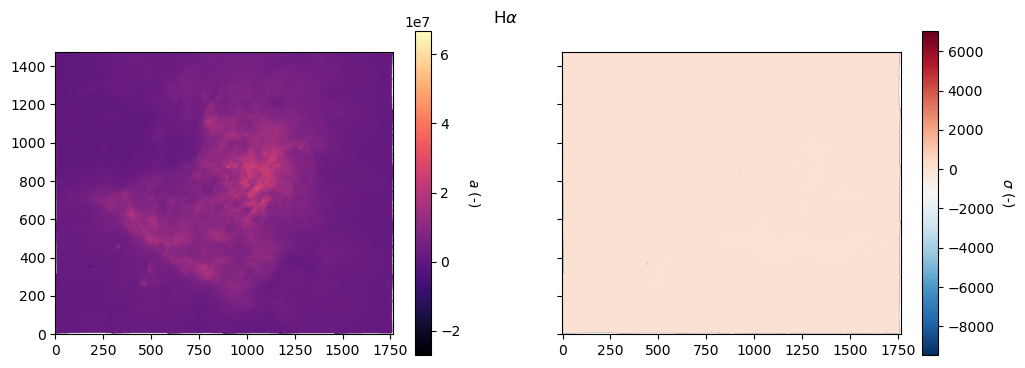

In [7]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [8]:
m = ~np.isfinite(sb) | (sb < 0.0)
sb[m] = 0.0
sb   /= sb.max()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\3387000891.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 0.8, 'H$\\alpha$')

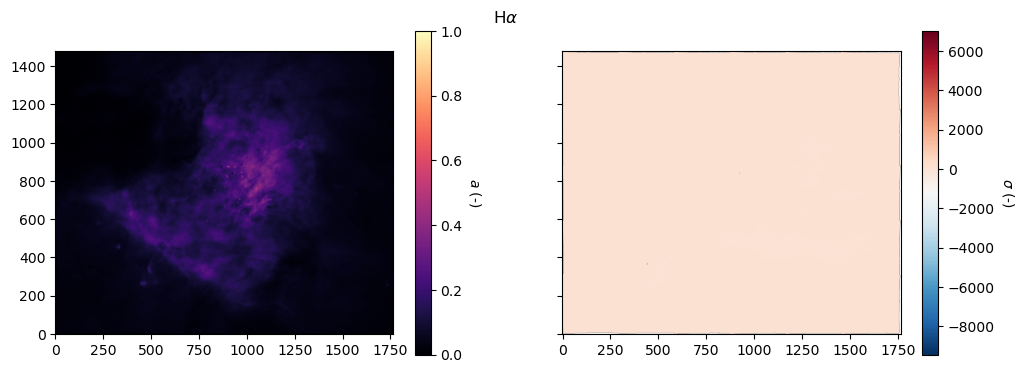

In [9]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

# Continuum

In [10]:
# Loading obs
hdul_cont = fits.open('observations/continuum-H_I-6563-bin001.fits')
hdr_cont = hdul_cont[0].header
print(hdul_cont.info())
print(hdr_cont)


Filename: observations/continuum-H_I-6563-bin001.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SCALED        1 ImageHDU        26   (1792, 1536)   float64   
  2  WEIGHT        1 ImageHDU        26   (1792, 1536)   float64   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  END                                                                                                                                                                                                                                                                                                                                                                                 

In [11]:
scaled = hdul_cont[1].data.astype(float)
weight = hdul_cont[2].data.astype(float)

In [12]:
trim = (slice(0, 1476),slice(0, 1766))
scaled = scaled[trim]

In [13]:
m = ~np.isfinite(scaled) | (scaled < 0.0)
scaled[m] = 0.0
scaled   /= scaled.max()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\1117279643.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 0.8, 'H$\\alpha$')

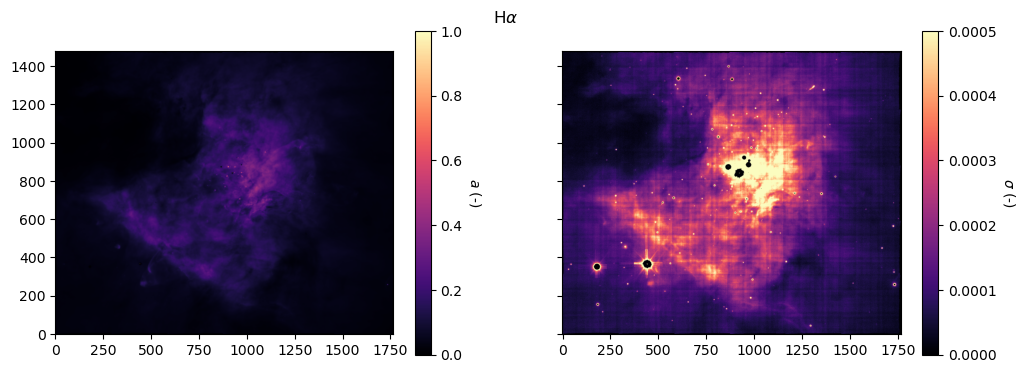

In [14]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="magma")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow( scaled,vmin = 0.0,vmax=0.0005, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

# Mask continuum

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\716080065.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\716080065.py:9: RuntimeWarning: divide by zero encountered in divide
  im = ax.imshow( sb/scaled,vmin=0, vmax=1000, **imshow_kwds)
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\716080065.py:9: RuntimeWarning: invalid value encountered in divide
  im = ax.imshow( sb/scaled,vmin=0, vmax=1000, **imshow_kwds)
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\716080065.py:12: RuntimeWarning: divide by zero encountered in divide
  im = axx.imshow(scaled/sb,vmin=0, vmax=0.002, **imshow_kwds2)
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\716080065.py:12: RuntimeWarning: invalid value encountered in divide
  im = axx.imshow(scaled/sb,vmin=0, vmax=0.002, **imshow_kwds2)

Text(0.5, 0.8, 'H$\\alpha$')

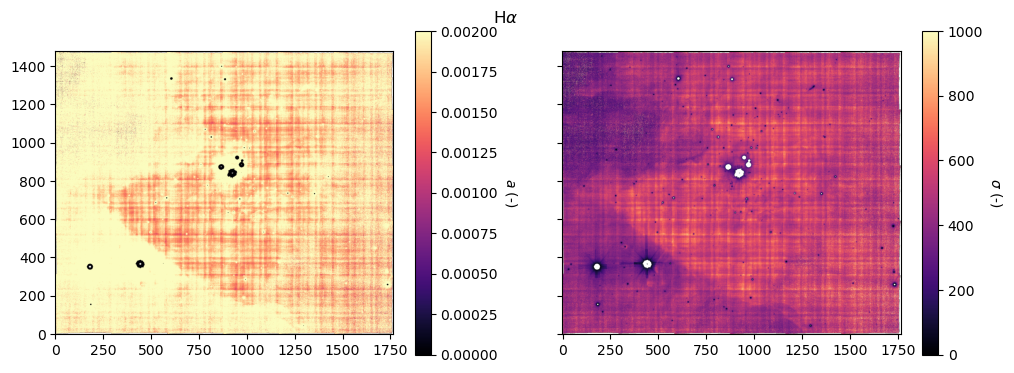

In [15]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="magma")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow( sb/scaled,vmin=0, vmax=1000, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(scaled/sb,vmin=0, vmax=0.002, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [16]:
scaled_sb = scaled/sb

C:\Users\javas\AppData\Local\Temp\ipykernel_29356\3266746249.py:1: RuntimeWarning: divide by zero encountered in divide
  scaled_sb = scaled/sb
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\3266746249.py:1: RuntimeWarning: invalid value encountered in divide
  scaled_sb = scaled/sb


In [17]:
m = ~np.isfinite(scaled_sb) | (scaled_sb < 0.0)
scaled_sb[m] = 0.0
scaled_sb   /= scaled_sb.max()

In [18]:
sb_scaled = sb/scaled

C:\Users\javas\AppData\Local\Temp\ipykernel_29356\2307350520.py:1: RuntimeWarning: divide by zero encountered in divide
  sb_scaled = sb/scaled
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\2307350520.py:1: RuntimeWarning: invalid value encountered in divide
  sb_scaled = sb/scaled


In [19]:
m = ~np.isfinite(sb_scaled) | (sb_scaled < 0.0)
sb_scaled[m] = 0.0
sb_scaled   /= sb_scaled.max()

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\2993969812.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 0.8, 'H$\\alpha$')

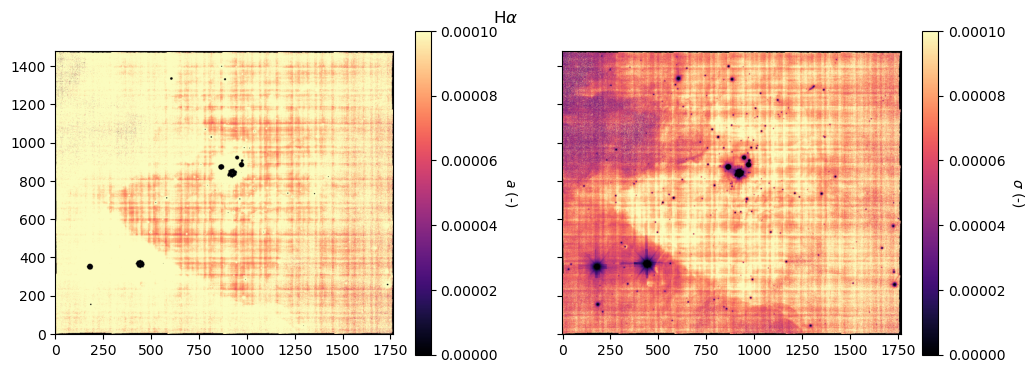

In [20]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="magma")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow( sb_scaled,vmin=0, vmax=0.0001, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(scaled_sb,vmin=0, vmax=0.0001, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [21]:
mask_cont = scaled_sb.astype(bool)

In [22]:
scaled_sb

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.00061165, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00068404, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [23]:
mask_cont

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False,  True, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [24]:
mu = vv.mean()
sb_m1 = np.where(mask_cont, sb, np.nan)
vv_m1 = np.where(mask_cont, vv, mu)    

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\javas\AppData\Local\Temp\ipykernel_29356\3469692439.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 0.8, 'H$\\alpha$')

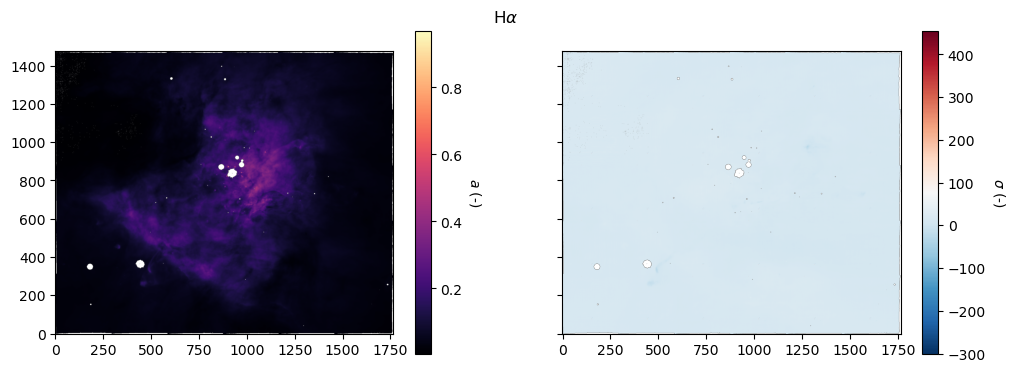

In [25]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv_m1, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_m1, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [26]:
xxx

NameError: name 'xxx' is not defined

# Mask vv

In [ ]:
# Loading obs
hdul_vv = fits.open("fits_ready/MUSE-M42-H-bin0.fits")
hdr_vv  = hdul_vv[0].header
print(hdul_vv .info())
#print(hdr_vv )
mask_vv = hdul_vv['MASK'].data.astype(bool)


In [ ]:
mu = vv.mean()
sb_m2 = np.where(mask_cont & mask_vv, sb, np.nan)
vv_m2 = np.where(mask_cont & mask_vv, vv, mu)   

In [ ]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv_m2, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_m2, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)
fig.suptitle(line, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

# Mask Sigma

In [ ]:
# Loading obs
hdul_sigma = fits.open("observations/sigma-H_I-6563-fuzz000.fits")
hdr_sigma = hdul_sigma[0].header
print(hdul_sigma.info())
print(hdr_sigma)

In [ ]:
sigma = hdul_sigma[0].data.astype(float)

In [ ]:
fig, axx = plt.subplots(figsize=(6, 6))

imshow_kwds2 = dict(origin="lower", cmap="viridis")

im = axx.imshow(sigma,vmin=50, vmax=55, **imshow_kwds2)
cbar = fig.colorbar(im, ax=axx, shrink=0.7)
cbar.set_label("sigma (km/s)", rotation=270, labelpad=15)

#fig.suptitle(line, y=0.95)

# plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')
plt.show()

# Downsample

In [ ]:
sb_d = sb
sigma_d = sigma

prod_map  = sb_d * sigma_d
sb_d_       = pd.notna(sb_d)
sigma_d_       = pd.notna(sigma_d)
prod_map_ = sb_d_ * sigma_d_

In [ ]:
bins = 4
mingoods  = [1]*bins

for mingood in zip(mingoods):
 [sb_d], sb_d_= downsample([sb_d], sb_d_, mingood=mingood)

for mingood in zip(mingoods):
 [prod_map], prod_map_= downsample([prod_map], prod_map_, mingood=mingood)

# Velocity binned map
sigma_d = prod_map/sb_d

In [ ]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="viridis")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(sigma_d,vmin=50, vmax=55, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_d, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

In [ ]:
sigma_o = oversample(sigma_d,16)

In [ ]:
fig, axx = plt.subplots(figsize=(6, 6))

imshow_kwds2 = dict(origin="lower", cmap="viridis")

im = axx.imshow(sigma_o,vmin=50,vmax=55, **imshow_kwds2)
cbar = fig.colorbar(im, ax=axx, shrink=0.7)
cbar.set_label("sigma (km/s)", rotation=270, labelpad=15)

#fig.suptitle(line, y=0.95)

# plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')
plt.show()

In [ ]:
sigma_m = np.where(sigma_o > 50, sigma_o, np.nan)

In [ ]:
fig, axx = plt.subplots(figsize=(6, 6))

imshow_kwds2 = dict(origin="lower", cmap="viridis")

im = axx.imshow(sigma_m,vmin=40,vmax=70, **imshow_kwds2)
cbar = fig.colorbar(im, ax=axx, shrink=0.7)
cbar.set_label("sigma (km/s)", rotation=270, labelpad=15)

#fig.suptitle(line, y=0.95)

# plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')
plt.show()

In [ ]:
sigma_m

In [ ]:
mask_sig = (~np.isnan(sigma_m)) & sigma_m.astype(bool)

In [ ]:
mask_sig

In [ ]:
trim_sig = (slice(0, 1472),slice(0, 1760))

In [ ]:
np.shape(mask_cont[trim_sig]), np.shape(mask_sig)

In [ ]:
mu = vv.mean()
sb_m3 = np.where(mask_cont[trim_sig] & ~mask_sig, sb[trim_sig], np.nan)
vv_m3 = np.where(mask_cont[trim_sig] & ~mask_sig, vv[trim_sig], mu)  

In [ ]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv_m3, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb_m3, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("$a$ (-)", rotation=270, labelpad=15)

In [ ]:
xxx

# Export

In [ ]:
#hdu_m0 = fits.ImageHDU(data=sb_m,  name='MOM0')
#hdu_m1 = fits.ImageHDU(data=vv_m,  name='MOM1')
#hdu_m2 = fits.ImageHDU(data=ss_m[trim],  name='MOM2')
#hdu_mk = fits.ImageHDU(data=good.astype(np.uint8) ,  name='MASK')

In [27]:
hdu_mk = fits.ImageHDU(data=mask_cont.astype(np.uint8) ,  name='MASK')
primary = fits.PrimaryHDU()
hdul = fits.HDUList([primary, hdu_mk])
hdul.writeto('fits_ready/mask_cont.fits', overwrite=True)

In [ ]:
#hdul = fits.HDUList([primary, hdu_m0, hdu_m1, hdu_mk])
#hdul.writeto('fits_ready/' + name_id + '.fits', overwrite=True)

with fits.open("fits_ready/" + name_id + ".fits") as hdul:
    hdul.info()
    
hdr = hdul[0].header
print(hdr)
